<a href="https://colab.research.google.com/github/rahman1487/Chatbot-Analytics-and-Optimization/blob/main/ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y transformers peft trl accelerate sentence-transformers

!pip install -q \
transformers==4.41.2 \
accelerate==0.30.1 \
datasets==2.19.2 \
evaluate==0.4.2 \
scikit-learn \
pandas \
numpy \
matplotlib \
seaborn \
openpyxl

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: sentence-transformers 5.5.1
Uninstalling sentence-transformers-5.5.1:
  Successfully uninstalled sentence-transformers-5.5.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 690.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
import transformers
import accelerate

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 4.41.2
Accelerate: 0.30.1


In [ ]:
from transformers import Trainer
from transformers import TrainingArguments

print("Trainer Loaded Successfully")

Trainer Loaded Successfully


In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(train_df.shape)
print(test_df.shape)

   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  
(120000, 3)
(7600, 3)


In [ ]:
train_df["text"] = (
    train_df["Title"].astype(str)
    + " "
    + train_df["Description"].astype(str)
)

test_df["text"] = (
    test_df["Title"].astype(str)
    + " "
    + test_df["Description"].astype(str)
)

train_df["label"] = train_df["Class Index"] - 1
test_df["label"] = test_df["Class Index"] - 1

train_df = train_df[["text","label"]]
test_df = test_df[["text","label"]]

print(train_df.head())

                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [ ]:
train_df = train_df.sample(
    n=5000,
    random_state=42
)

test_df = test_df.sample(
    n=1000,
    random_state=42
)

print(train_df.shape)
print(test_df.shape)

(5000, 2)
(1000, 2)


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
results = []

confusion_matrices = {}

def train_model(model_name):

    print(f"\nTraining {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(
        model_name
    )

    def tokenize(batch):

        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=64
        )

    train_tok = train_dataset.map(
        tokenize,
        batched=True
    )

    test_tok = test_dataset.map(
        tokenize,
        batched=True
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4
    )

    training_args = TrainingArguments(
        output_dir=f"./{model_name}",
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        compute_metrics=compute_metrics
    )

    start_time = time.time()

    trainer.train()

    training_time = time.time() - start_time

    predictions = trainer.predict(
        test_tok
    )

    y_true = predictions.label_ids

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    confusion_matrices[model_name] = cm

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        training_time
    ])

In [ ]:
import requests

r = requests.get(
    "https://huggingface.co/bert-base-uncased/raw/main/config.json"
)

print(r.status_code)

200


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

print("Tokenizer Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer Loaded


In [ ]:
train_model(
    "bert-base-uncased"
)


Training bert-base-uncased


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.533325
200,0.303491
300,0.326798


In [ ]:
train_model(
    "roberta-base"
)


Training roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.555129
200,0.341573
300,0.334021


In [ ]:
train_model(
    "distilbert-base-uncased"
)


Training distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.588414
200,0.311340
300,0.334665


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,bert-base-uncased,0.898,0.897744,0.898,0.897772,52.771179
1,roberta-base,0.902,0.902540,0.902,0.901949,59.154504
2,distilbert-base-uncased,0.895,0.894600,0.895,0.894723,32.144606


In [ ]:
results_df.to_csv(
    "Transformer_Results.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,bert-base-uncased,0.898,0.897744,0.898,0.897772,52.771179
1,roberta-base,0.902,0.902540,0.902,0.901949,59.154504
2,distilbert-base-uncased,0.895,0.894600,0.895,0.894723,32.144606


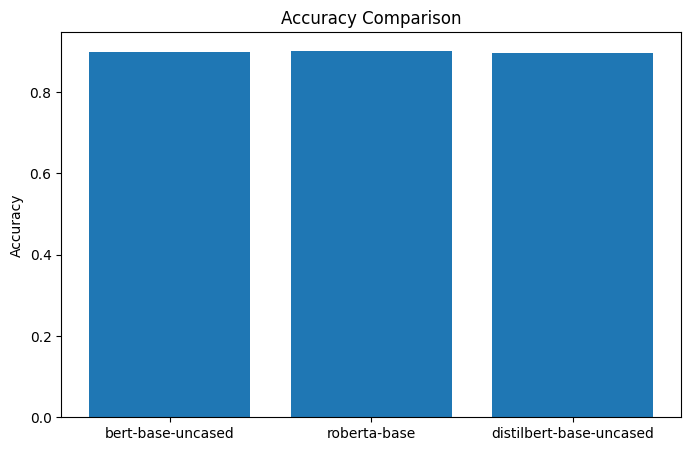

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title(
    "Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

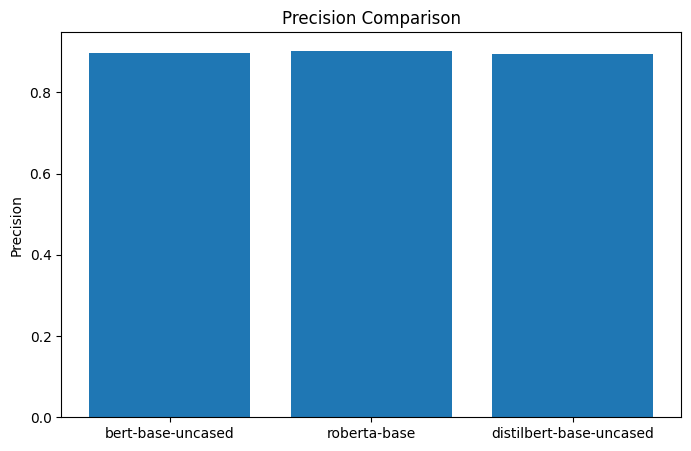

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Precision"]
)

plt.title(
    "Precision Comparison"
)

plt.ylabel(
    "Precision"
)

plt.show()

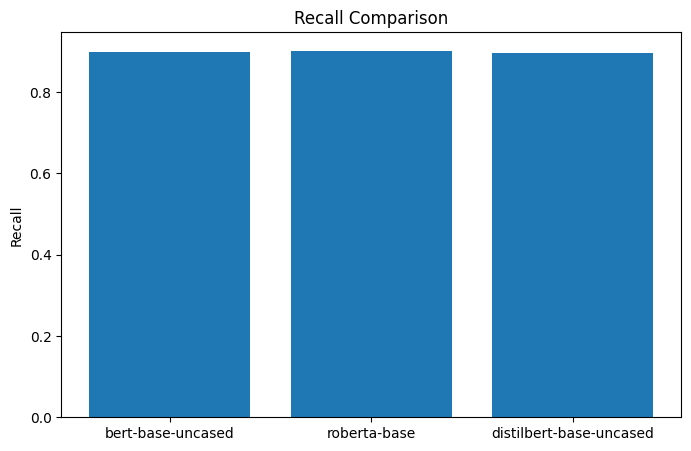

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Recall"]
)

plt.title(
    "Recall Comparison"
)

plt.ylabel(
    "Recall"
)

plt.show()

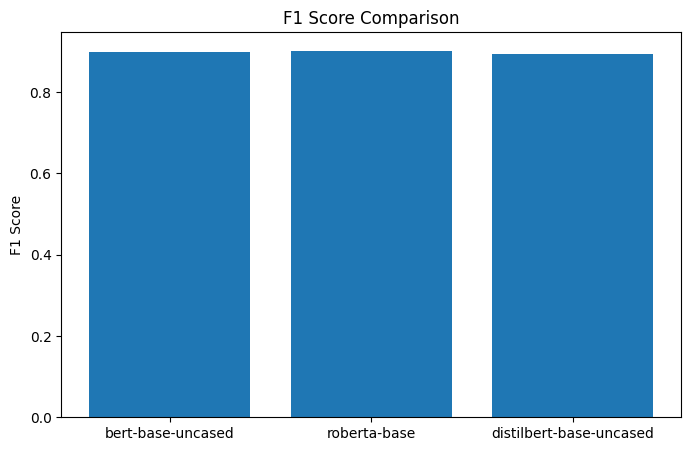

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title(
    "F1 Score Comparison"
)

plt.ylabel(
    "F1 Score"
)

plt.show()

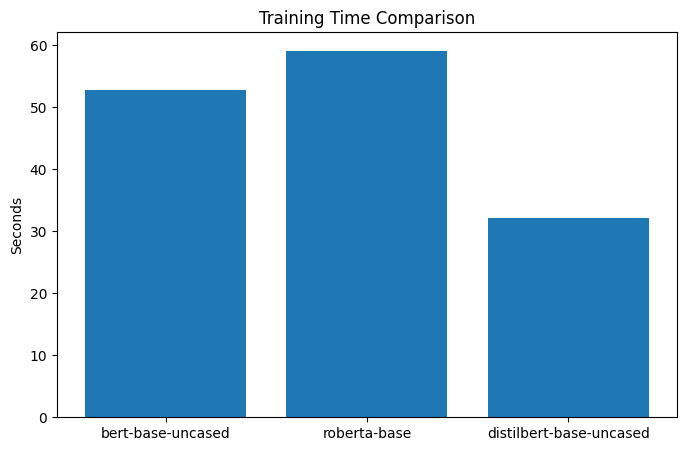

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Training Time"]
)

plt.title(
    "Training Time Comparison"
)

plt.ylabel(
    "Seconds"
)

plt.show()

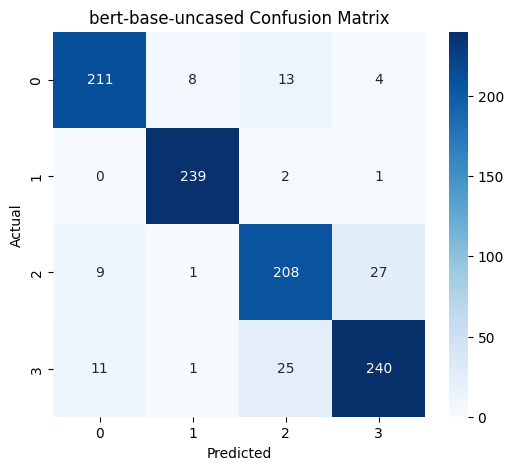

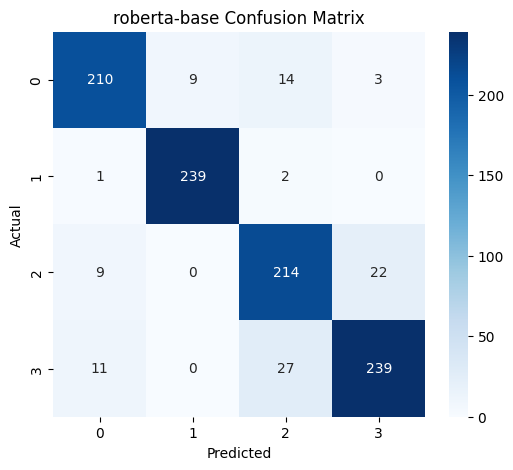

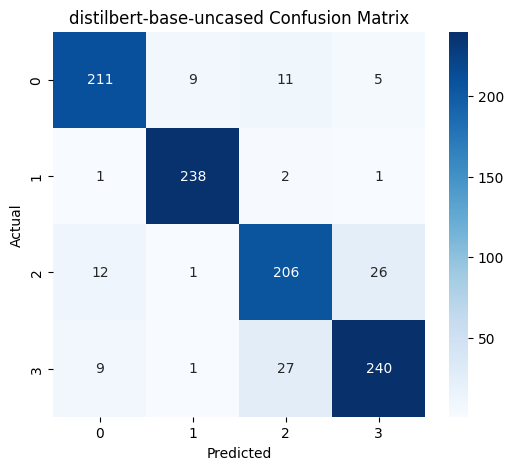

In [ ]:
for model_name, cm in confusion_matrices.items():

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()


Question 1:   Q1. What is your current academic or professional discipline?  
                                                    Frequency  Percentage
  Q1. What is your current academic or professi...                       
Artificial Intelligence / Data Science                     18        36.0
Computer Science / Information Technology                  14        28.0
Business / Management                                      11        22.0
Other                                                       7        14.0


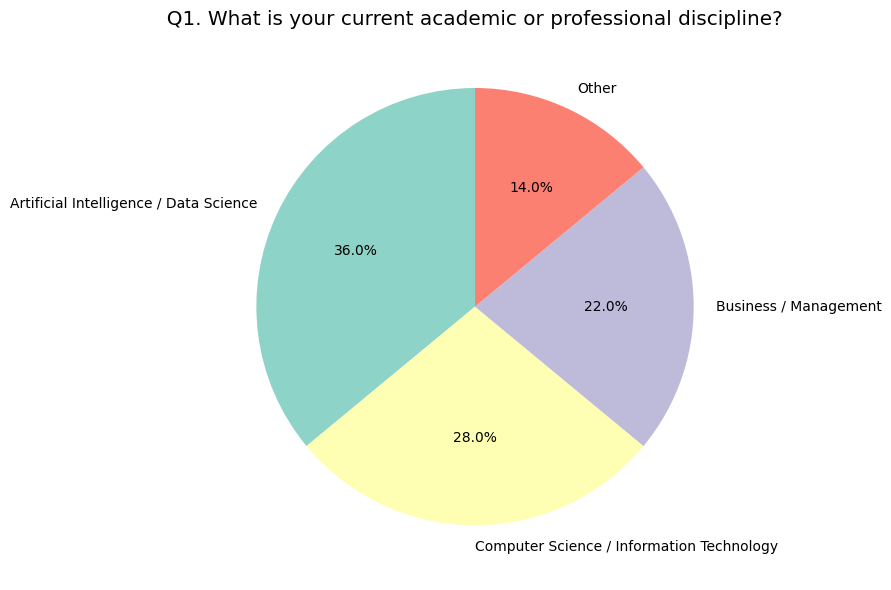


Question 2:   Q2. How would you describe your level of knowledge regarding Artificial Intelligence and Machine Learning technologies?  
                                                    Frequency  Percentage
  Q2. How would you describe your level of know...                       
Intermediate                                               20        40.0
Basic                                                      13        26.0
Advanced                                                   10        20.0
No Prior Knowledge                                          7        14.0


/tmp/ipykernel_504/721125890.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


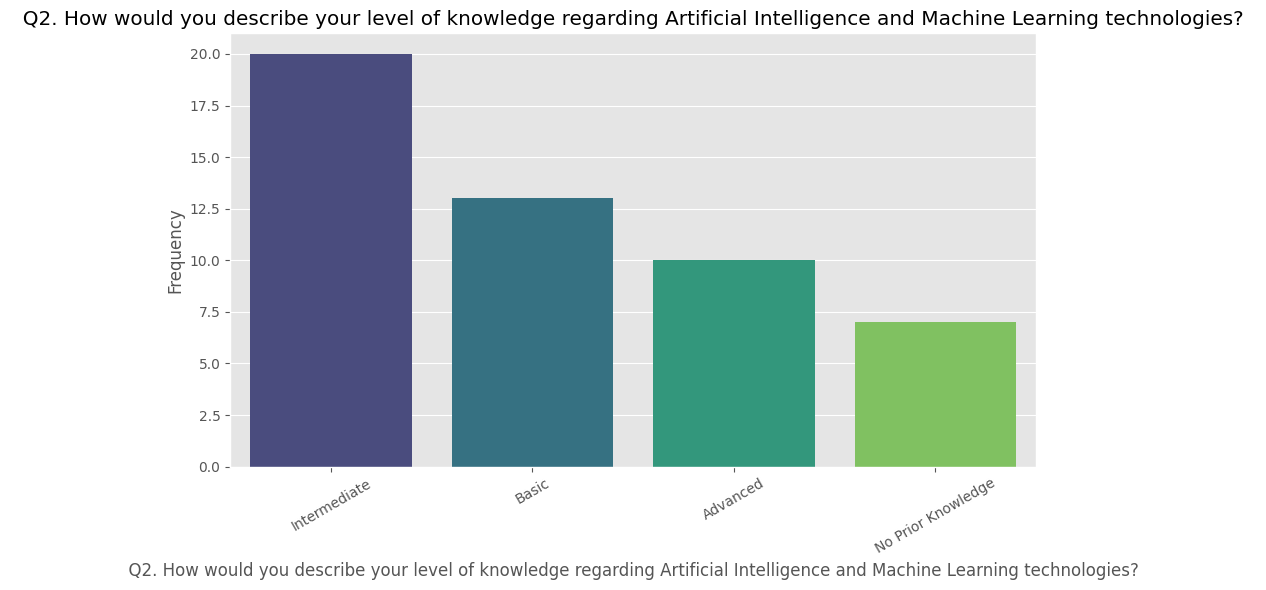


Question 3:   Q3. How familiar are you with the concept of Natural Language Processing (NLP)?  
                                                    Frequency  Percentage
  Q3. How familiar are you with the concept of ...                       
Slightly Familiar                                          18        36.0
Moderately Familiar                                        15        30.0
Not Familiar                                               12        24.0
Very Familiar                                               5        10.0


/tmp/ipykernel_504/721125890.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


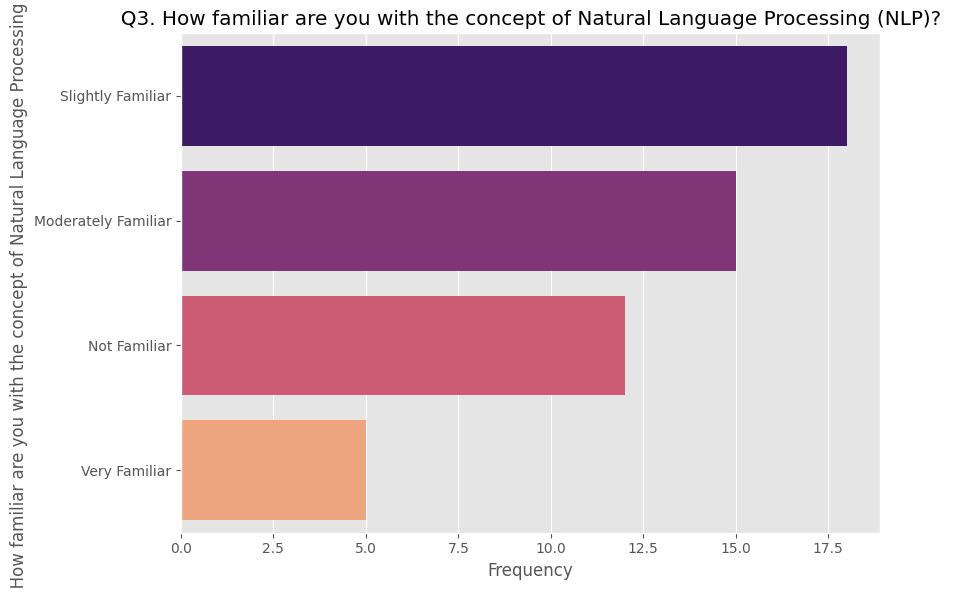


Question 4:   Q4. To what extent are you aware of text classification applications used in modern digital systems?  
                                                    Frequency  Percentage
  Q4. To what extent are you aware of text clas...                       
Not Aware                                                  16        32.0
Slightly Aware                                             16        32.0
Moderately Aware                                           12        24.0
Highly Aware                                                6        12.0


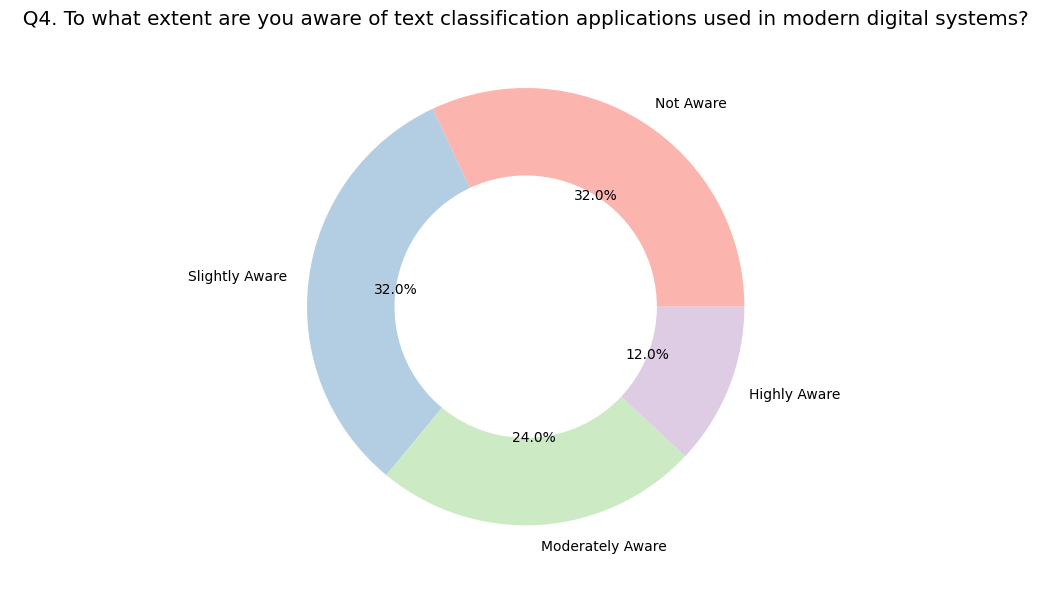


Question 5:   Q5. How frequently do you interact with AI-based systems that automatically process or categorize textual information?  
                                                    Frequency  Percentage
  Q5. How frequently do you interact with AI-ba...                       
Occasionally                                               21        42.0
Frequently                                                 11        22.0
Rarely                                                     10        20.0
Never                                                       8        16.0


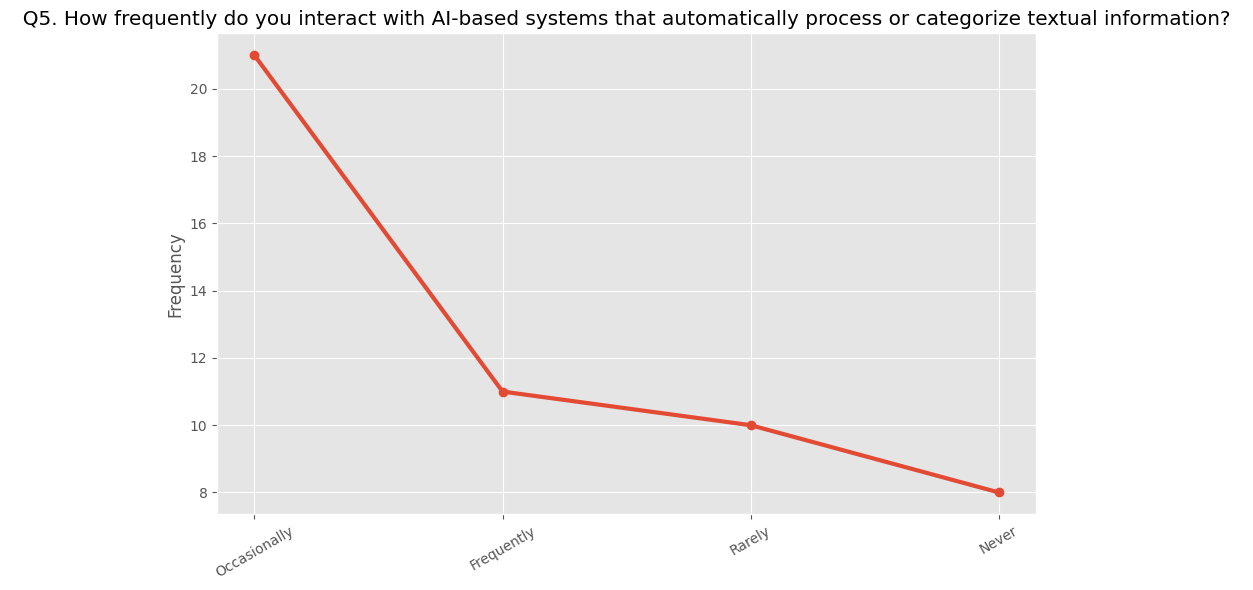


Question 6:   Q6. How familiar are you with transformer-based language models used in Natural Language Processing?  
                                                    Frequency  Percentage
  Q6. How familiar are you with transformer-bas...                       
Slightly Familiar                                          17        34.0
Moderately Familiar                                        16        32.0
Not Familiar                                                9        18.0
Very Familiar                                               8        16.0


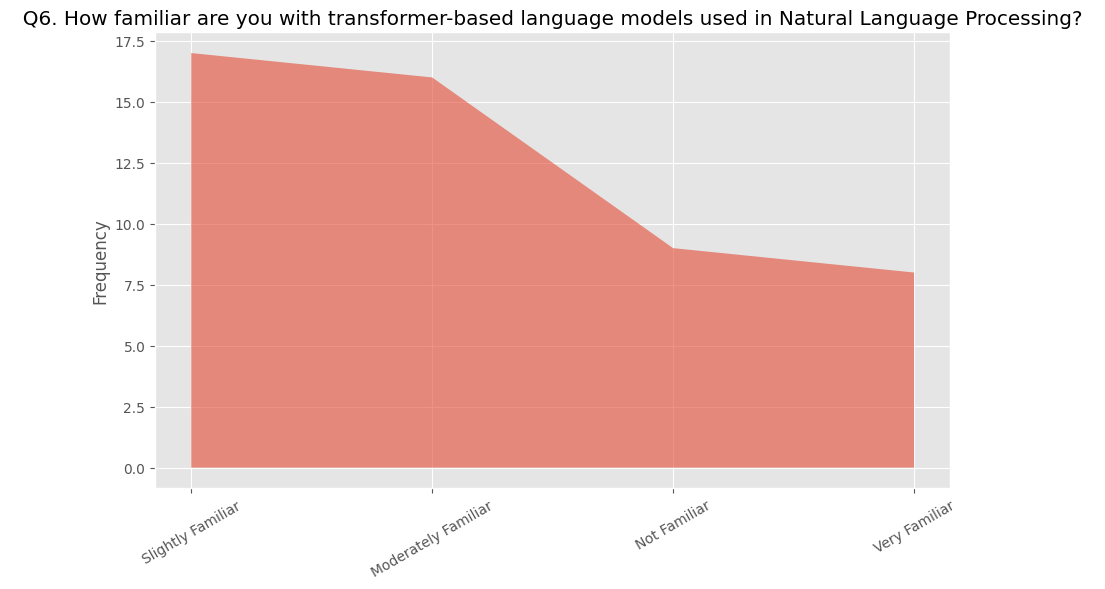


Question 7:   Q7. Which of the following transformer models are you most familiar with?  
                                                    Frequency  Percentage
  Q7. Which of the following transformer models...                       
DistilBERT                                                 21        42.0
None of the Above                                          14        28.0
RoBERTa                                                    11        22.0
BERT                                                        4         8.0


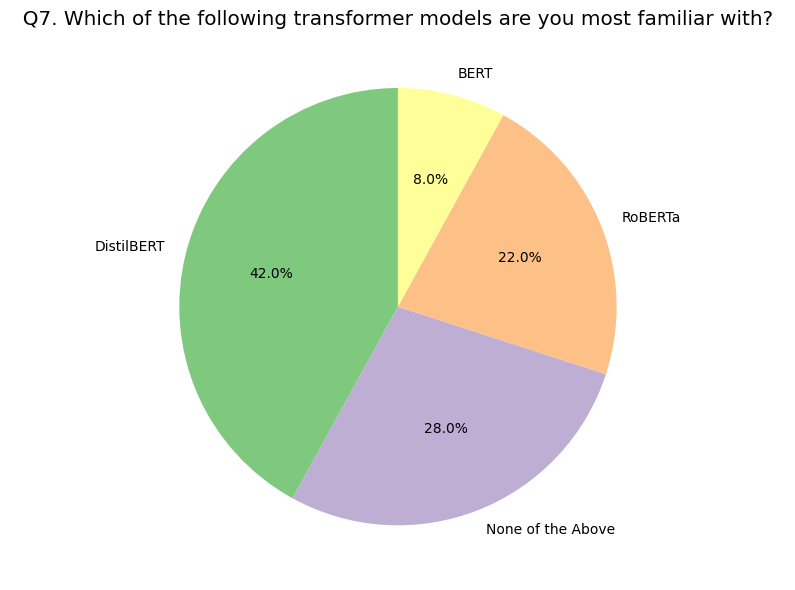


Question 8:   Q8. Which characteristic of transformer models do you consider most valuable for text classification tasks?  
                                                    Frequency  Percentage
  Q8. Which characteristic of transformer model...                       
Computational Efficiency                                   21        42.0
Contextual Understanding                                   11        22.0
Ease of Implementation                                     10        20.0
Classification Accuracy                                     8        16.0


/tmp/ipykernel_504/721125890.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


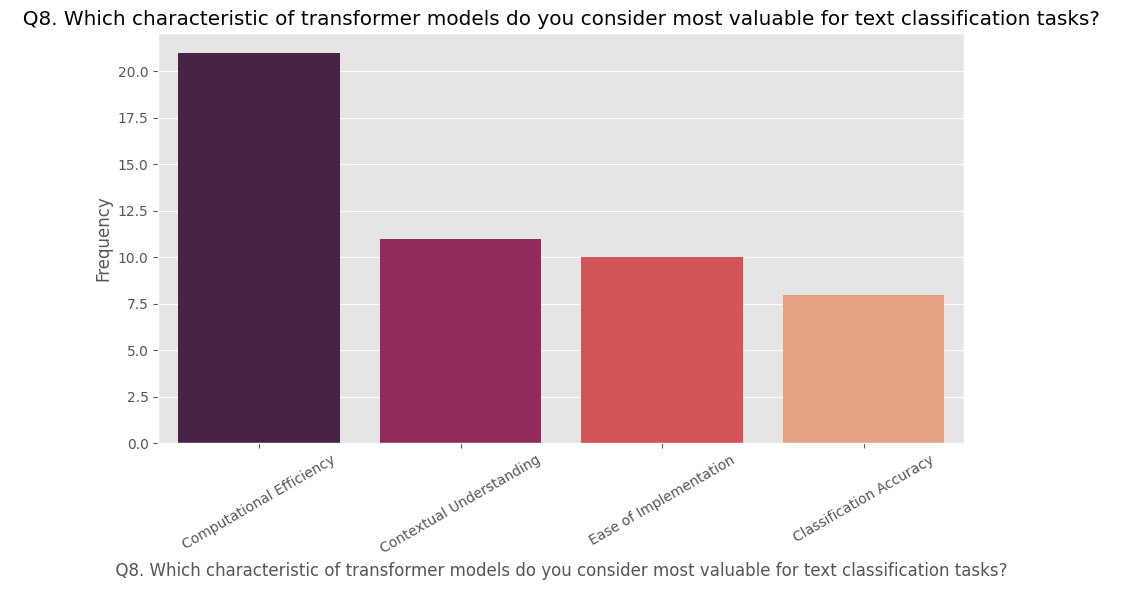


Question 9:   Q9. How important is model accuracy when evaluating the effectiveness of a text classification system?  
                                                    Frequency  Percentage
  Q9. How important is model accuracy when eval...                       
Moderately Important                                       18        36.0
Slightly Important                                         14        28.0
Very Important                                             12        24.0
Extremely Important                                         6        12.0


/tmp/ipykernel_504/721125890.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


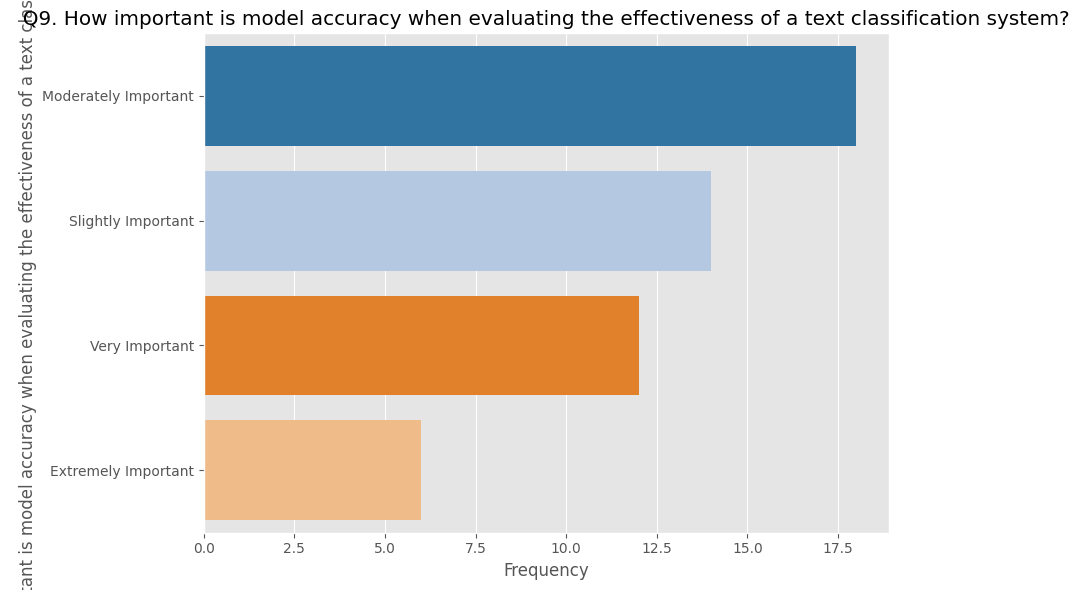


Question 10:   Q10. How important is computational efficiency when selecting a machine learning model for practical deployment?  
                                                    Frequency  Percentage
  Q10. How important is computational efficienc...                       
Moderately Important                                       15        30.0
Very Important                                             13        26.0
Extremely Important                                        11        22.0
Slightly Important                                         11        22.0


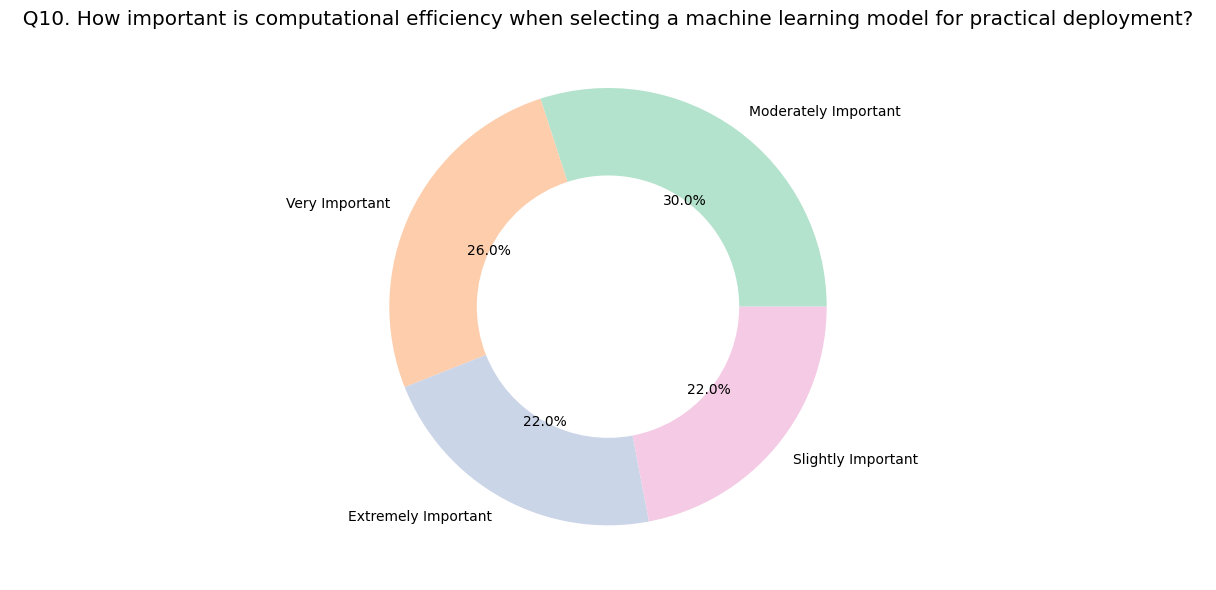


Question 11:   Q11. Which evaluation criterion would you prioritize when comparing text classification models?  
                                                    Frequency  Percentage
  Q11. Which evaluation criterion would you pri...                       
Precision                                                  17        34.0
F1-Score                                                   15        30.0
Recall                                                      9        18.0
Accuracy                                                    9        18.0


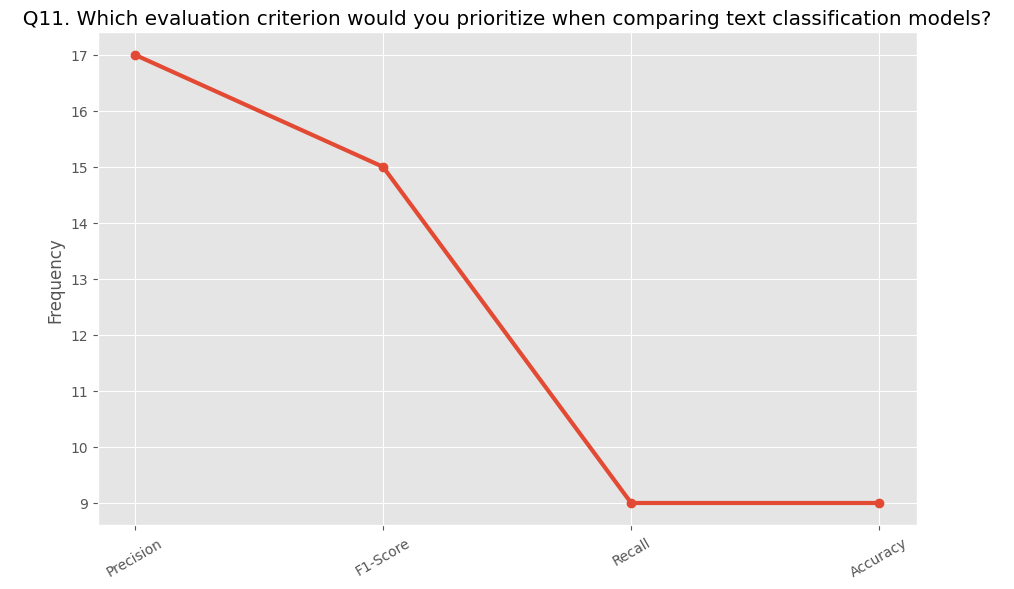


Question 12:   Q12. Based on your understanding, which transformer model is likely to achieve the highest performance in text classification tasks?  
                                                    Frequency  Percentage
  Q12. Based on your understanding, which trans...                       
DistilBERT                                                 15        30.0
Unsure                                                     13        26.0
RoBERTa                                                    12        24.0
BERT                                                       10        20.0


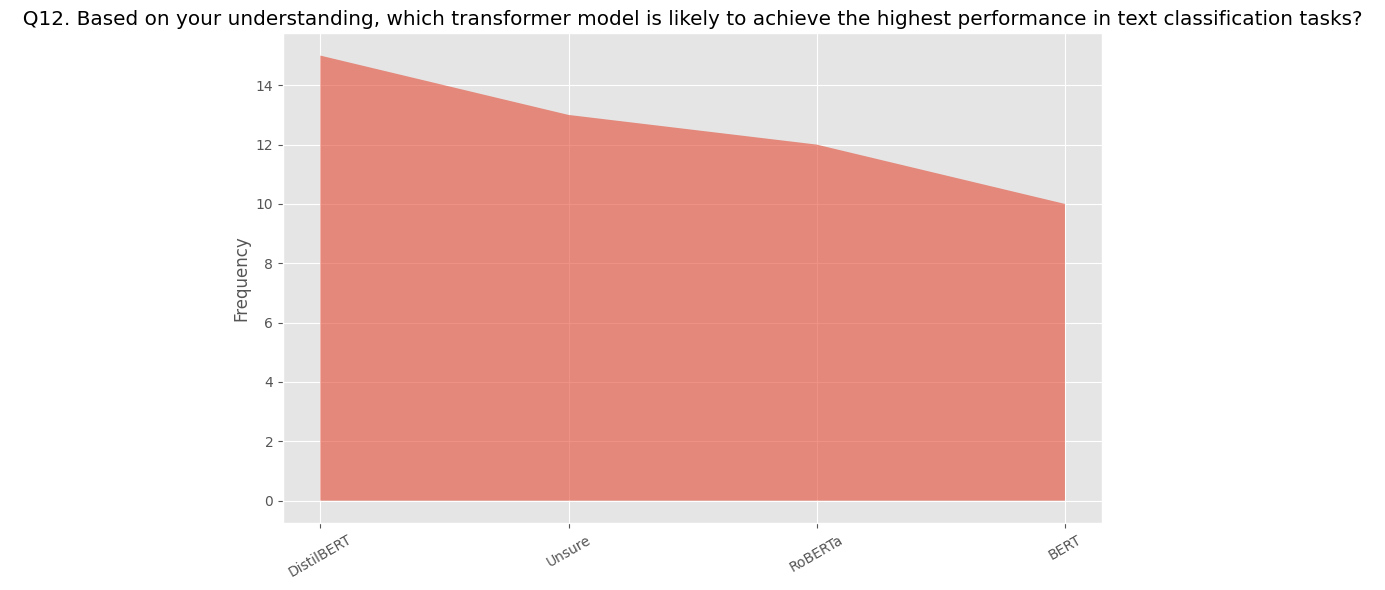


Question 13:   Q13. How effective do you believe transformer-based models are for real-world text classification applications?  
                                                    Frequency  Percentage
  Q13. How effective do you believe transformer...                       
Ineffective                                                18        36.0
Effective                                                  14        28.0
Moderately Effective                                       13        26.0
Highly Effective                                            5        10.0


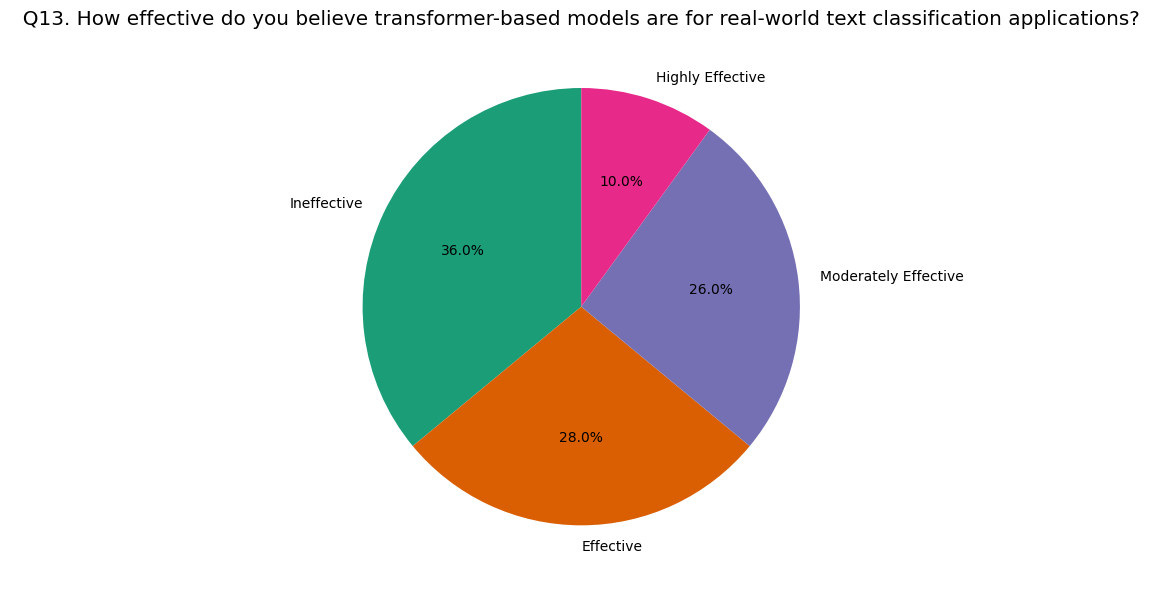


Question 14:   Q14. To what extent do you believe organizations will increase their adoption of transformer-based models in future NLP applications?  
                                                    Frequency  Percentage
  Q14. To what extent do you believe organizati...                       
To a Limited Extent                                        19        38.0
To a Moderate Extent                                       12        24.0
Not at All                                                 10        20.0
To a Great Extent                                           9        18.0


/tmp/ipykernel_504/721125890.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


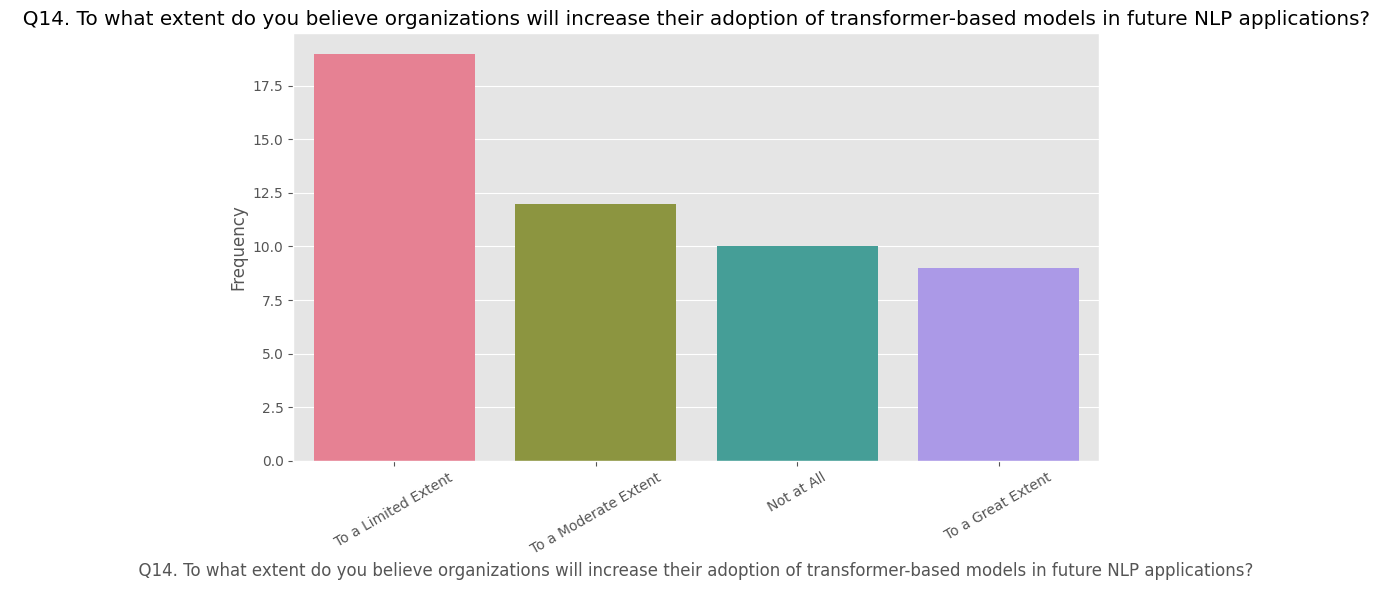


Question 15:   Q15. Which statement best reflects your view regarding the future of transformer-based models in text classification?  
                                                    Frequency  Percentage
  Q15. Which statement best reflects your view ...                       
They will become the dominant approach in text ...         21        42.0
They will be widely adopted alongside tradition...         14        28.0
Their adoption will remain limited to specializ...         12        24.0
Their long-term impact is uncertain.                        3         6.0


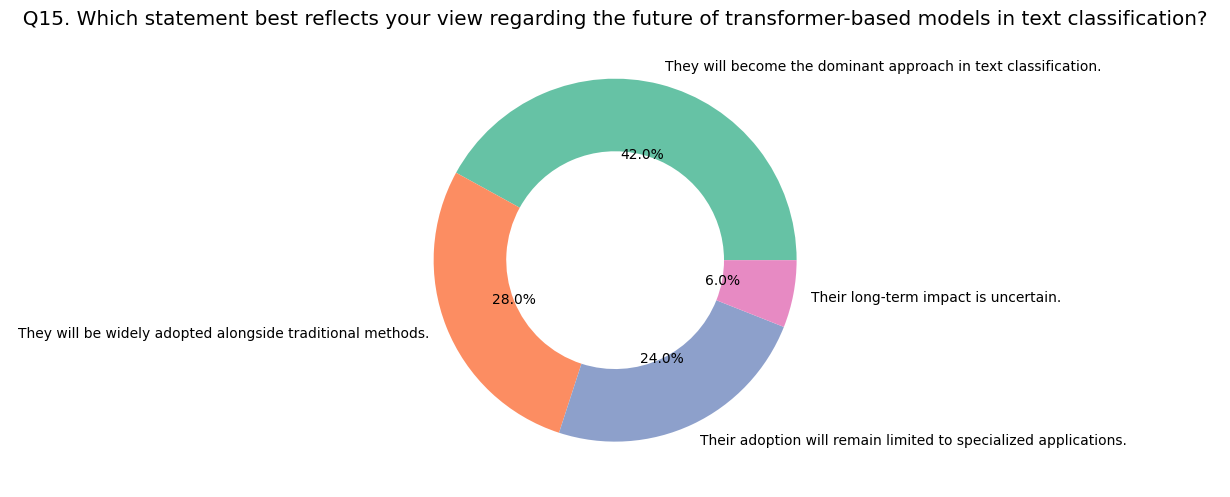

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('ggplot')

df = pd.read_excel("Untitled form (Responses).xlsx")

questions = df.columns[1:]

chart_styles = [
    "pie",
    "bar",
    "barh",
    "donut",
    "line",
    "area",
    "pie",
    "bar",
    "barh",
    "donut",
    "line",
    "area",
    "pie",
    "bar",
    "donut"
]

color_palettes = [
    "Set3",
    "viridis",
    "magma",
    "Pastel1",
    "coolwarm",
    "crest",
    "Accent",
    "rocket",
    "tab20",
    "Pastel2",
    "flare",
    "cubehelix",
    "Dark2",
    "husl",
    "Set2"
]

for i, col in enumerate(questions):

    print("\n" + "="*80)
    print(f"Question {i+1}: {col}")
    print("="*80)

    freq = df[col].value_counts()

    percent = round(
        (freq / freq.sum()) * 100,
        2
    )

    summary = pd.DataFrame({
        "Frequency": freq,
        "Percentage": percent
    })

    print(summary)

    colors = sns.color_palette(
        color_palettes[i],
        len(freq)
    )

    plt.figure(figsize=(9,6))

    chart_type = chart_styles[i]

    if chart_type == "pie":

        plt.pie(
            freq,
            labels=freq.index,
            autopct="%1.1f%%",
            colors=colors,
            startangle=90
        )

        plt.title(col)

    elif chart_type == "donut":

        plt.pie(
            freq,
            labels=freq.index,
            autopct="%1.1f%%",
            colors=colors,
            wedgeprops={"width":0.4}
        )

        plt.title(col)

    elif chart_type == "bar":

        sns.barplot(
            x=freq.index,
            y=freq.values,
            palette=color_palettes[i]
        )

        plt.xticks(rotation=30)
        plt.ylabel("Frequency")
        plt.title(col)

    elif chart_type == "barh":

        sns.barplot(
            y=freq.index,
            x=freq.values,
            palette=color_palettes[i]
        )

        plt.xlabel("Frequency")
        plt.title(col)

    elif chart_type == "line":

        plt.plot(
            freq.index,
            freq.values,
            marker='o',
            linewidth=3
        )

        plt.xticks(rotation=30)
        plt.ylabel("Frequency")
        plt.title(col)

    elif chart_type == "area":

        plt.fill_between(
            range(len(freq)),
            freq.values,
            alpha=0.6
        )

        plt.xticks(
            range(len(freq)),
            freq.index,
            rotation=30
        )

        plt.ylabel("Frequency")
        plt.title(col)

    plt.tight_layout()

    plt.show()